## 재정데이터를 활용한 분석 실습(2)

- 데이터프레임 합치기

In [1]:
!pip3 install pandas
!pip3 install koreanize_matplotlib
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [20]:
# 데이터 전처리(09)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 과학적 표기법 해제
pd.options.display.float_format = '{:.0f}'.format

# 2021년 데이터 처리
df1 = pd.read_csv("Practice Data/분야별 세출현황_2021.csv")
df1 = df1[['회계연도','지역명','분야명','예산현액','지출액']]
df1[df1['지역명'] == '서울' ]
df1['차액'] = df1['예산현액'] - df1['지출액']

df1 = df1[['회계연도','분야명','차액']]

# 2022년 데이터 처리
df2 = pd.read_csv("Practice Data/분야별 세출현황_2022.csv")
df2 = df2[['회계연도','지역명','분야명','예산현액','지출액']]
df2[df2['지역명'] == '서울' ]
df2['차액'] = df2['예산현액'] - df2['지출액']

df2 = df2[['회계연도','분야명','차액']]

# 2023년 데이터 처리
df3 = pd.read_csv("Practice Data/분야별 세출현황_2023.csv")
df3.columns = df3.columns.str.strip()
df3 = df3[['회계연도','지역명','분야명','예산현액','지출액']]
df3[df3['지역명'] == '서울' ]
df3['차액'] = df3['예산현액'] - df3['지출액']

df3 = df3[['회계연도','분야명','차액']]



In [ ]:
#인덱스 문제 발생
result = pd.concat([df1,df2,df3])
result

#인덱스 재지정하기(drop : 기존 인덱스 / inplace = 바로 저장 )
result.reset_index(drop = True, inplace=True)
result


,회계연도,분야명,차액
0,2021,일반공공행정,5421150000000
1,2021,공공질서및안전,1316071000000
2,2021,교육,2812276000000
3,2021,문화및관광,538381000000
4,2021,환경,800218000000
...,...,...,...
9534,2023,교통및물류,483398000000
9535,2023,국토및지역개발,402387000000
9536,2023,과학기술,1001063490
9537,2023,예비비,62422994000


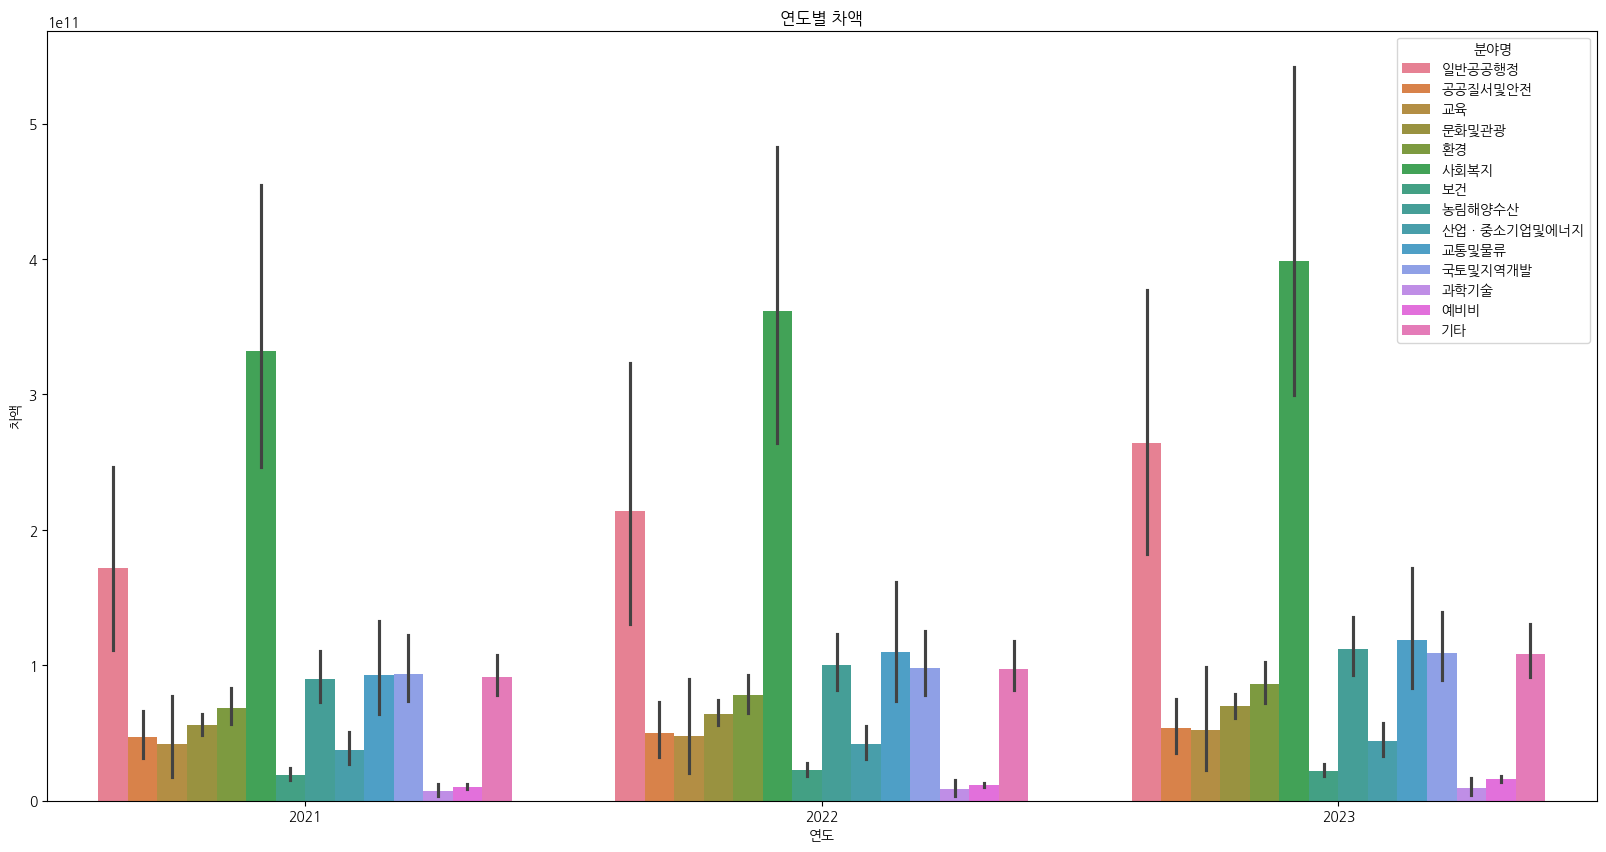

In [21]:
# seaborn으로 막대그래프 그리기

import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(20,10))

sns.barplot(data=result, x='회계연도', y='차액', hue='분야명')

plt.title("연도별 차액")
plt.xlabel('연도')
plt.ylabel('차액')

plt.show()

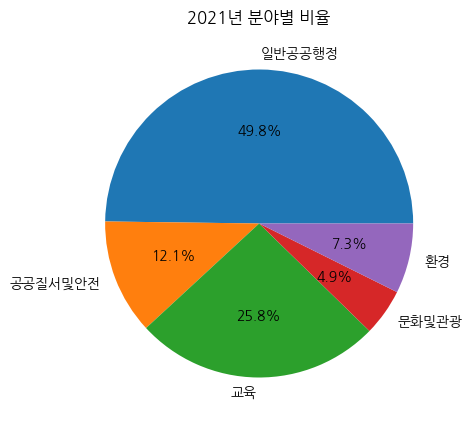

In [ ]:
# matplotlib로 원 그래프 그리기

#분야명 항목 중 5개만 추출
df1 = df1.iloc[:5]
df1

plt.figure(figsize=(5,5))
plt.pie(df1['차액'],labels=df1['분야명'],autopct=('%.1f%%'))

plt.title("2021년 분야별 비율")
plt.show()

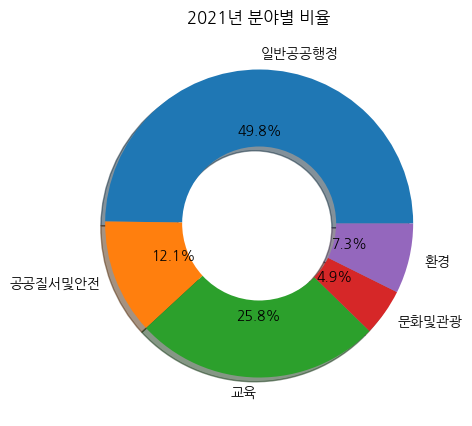

In [26]:
# # matplotlib로  도넛 그래프 그리기
# df1 = df1.iloc[:5]

plt.figure(figsize=(5,5))
plt.pie(df1['차액'],labels=df1['분야명'],autopct='%.1f%%', startangle=0, shadow=True, wedgeprops=dict(width=0.5))

plt.title("2021년 분야별 비율")
plt.show()